# Compare accumulated heat and mean temps to establish non-linearity

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
import pwlf #piecewise linear fits

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

## Load summer stats

In [2]:
ds = xr.open_dataset('../../../Data/ERA5-global/Analysis/New-Fourier/1961-2023_ALL_summer_stats.nc')
ds

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

In [3]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"

In [4]:
# can be land and inland small water
ds_land = ds.where(ds.lsm > 0.5)
ds_ocean = ds.where(ds.lsm <= 0.5)

## Plot Mean Heat over time Land vs Ocean

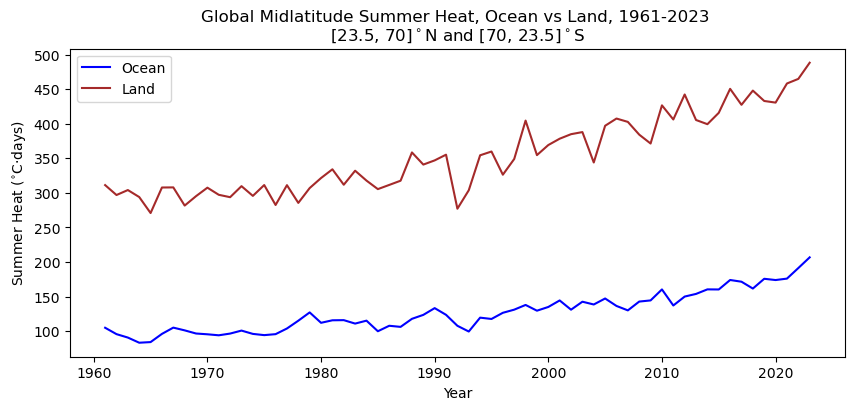

In [6]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_heat = ds_land.SummerHeat.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_heat = ds_ocean.SummerHeat.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_heat.time.dt.year, wavg_midlat_ocean_heat, label="Ocean", color='blue')
plt.plot(wavg_midlat_land_heat.time.dt.year, wavg_midlat_land_heat, label="Land", color='brown')
plt.xlabel("Year")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.title("Global Midlatitude Summer Heat, Ocean vs Land, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

## Plot Mean T over time Land vs Ocean

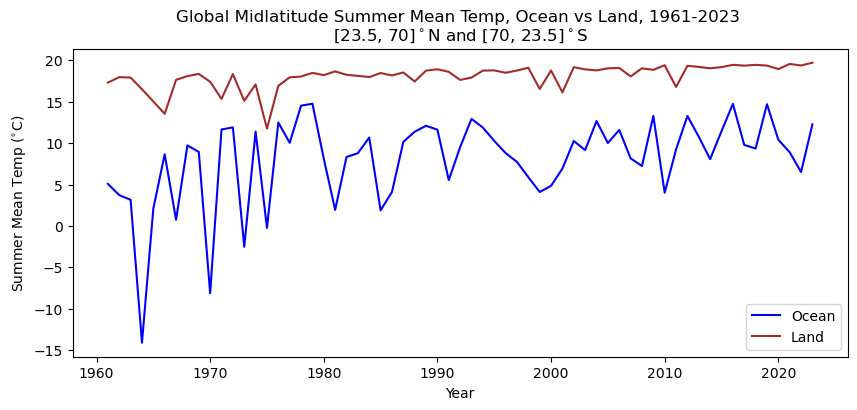

In [8]:
# convert from K to C
KtoC = -273.15

# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_meantemp = ds_land.SummerMeanT.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon']) + KtoC
wavg_midlat_ocean_meantemp = ds_ocean.SummerMeanT.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon']) + KtoC



plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_meantemp.time.dt.year, wavg_midlat_ocean_meantemp, label="Ocean", color='blue')
plt.plot(wavg_midlat_land_meantemp.time.dt.year, wavg_midlat_land_meantemp, label="Land", color='brown')
plt.xlabel("Year")
plt.ylabel("Summer Mean Temp ($^{\circ}$C)")
plt.title("Global Midlatitude Summer Mean Temp, Ocean vs Land, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

## Now Mean Heat vs Mean T

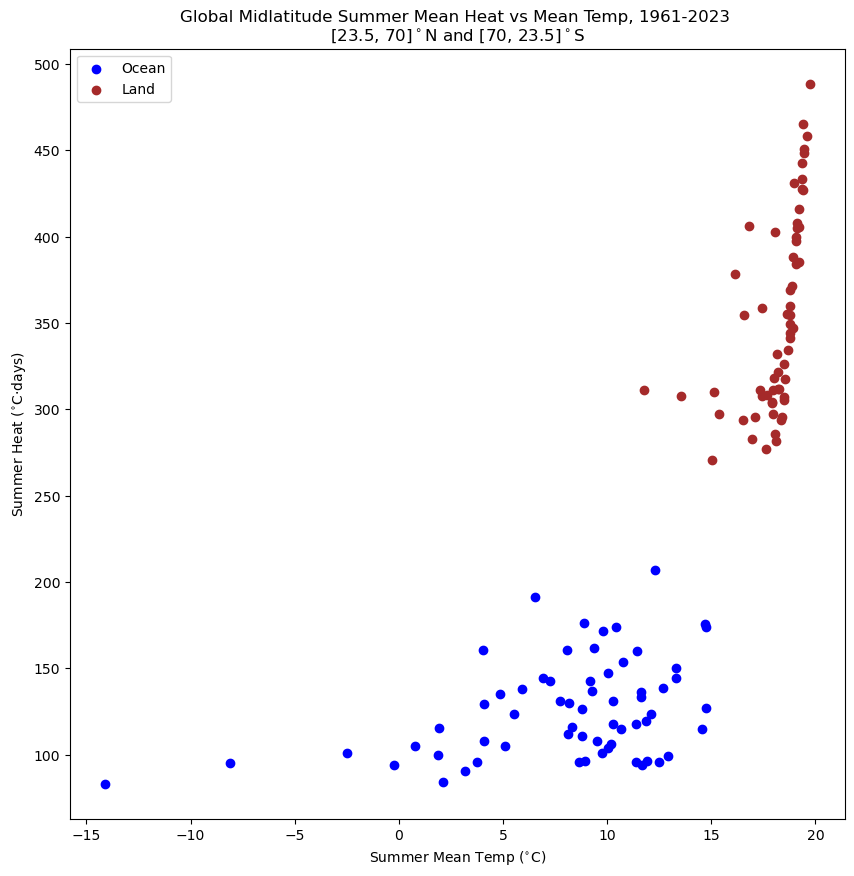

In [11]:
plt.figure(figsize=(10,10))
plt.scatter(x=wavg_midlat_ocean_meantemp, y=wavg_midlat_ocean_heat, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp, y=wavg_midlat_land_heat, label="Land", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.title("Global Midlatitude Summer Mean Heat vs Mean Temp, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

## Analysis Period Only

In [16]:
wavg_midlat_land_meantemp_an = wavg_midlat_land_meantemp.sel(time=slice('1990','2023'))
wavg_midlat_ocean_meantemp_an = wavg_midlat_ocean_meantemp.sel(time=slice('1990','2023'))
wavg_midlat_land_heat_an = wavg_midlat_land_heat.sel(time=slice('1990','2023'))
wavg_midlat_ocean_heat_an = wavg_midlat_ocean_heat.sel(time=slice('1990','2023'))


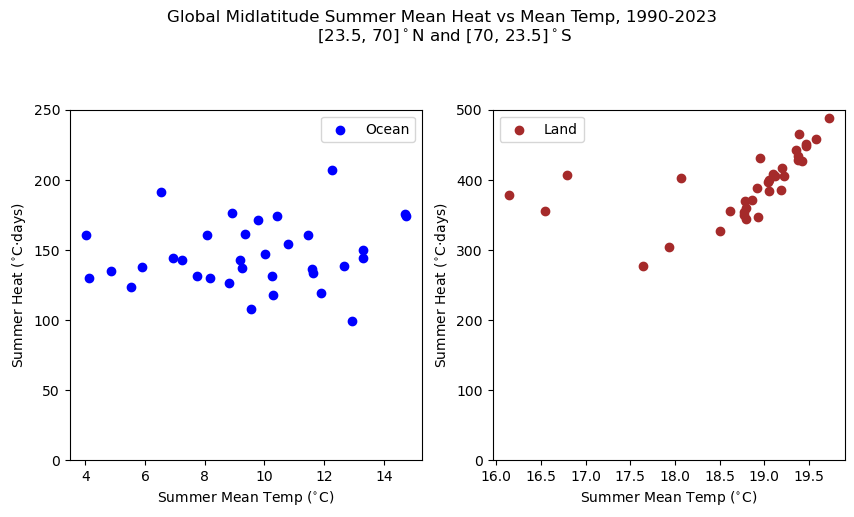

In [22]:
plt.figure(figsize=(10,10))
plt.subplot(221)
plt.scatter(x=wavg_midlat_ocean_meantemp_an, y=wavg_midlat_ocean_heat_an, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(0,250)
plt.legend()
plt.subplot(222)
plt.scatter(x=wavg_midlat_land_meantemp_an, y=wavg_midlat_land_heat_an, label="Land", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(0,500)
plt.suptitle("Global Midlatitude Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

### Split into Inland/Coast/Ocean

In [23]:
wavg_midlat_inland_meantemp_an = wavg_midlat_land_meantemp_an.where(ds.Coastal == False)
wavg_midlat_coast_meantemp_an = wavg_midlat_land_meantemp_an.where(ds.Coastal)

wavg_midlat_inland_heat_an = wavg_midlat_land_heat_an.where(ds.Coastal == False)
wavg_midlat_coast_heat_an = wavg_midlat_land_heat_an.where(ds.Coastal)

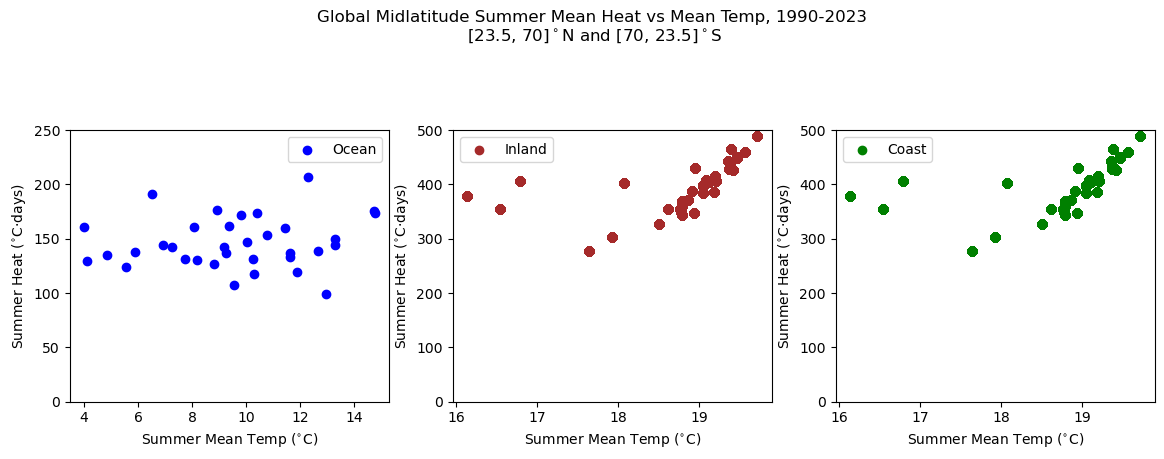

CPU times: user 2min 3s, sys: 29.2 s, total: 2min 32s
Wall time: 2min 41s


In [26]:
%%time

# takes 2.5 min

plt.figure(figsize=(14,12))
plt.subplot(331)
plt.scatter(x=wavg_midlat_ocean_meantemp_an, y=wavg_midlat_ocean_heat_an, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(0,250)
plt.legend()
plt.subplot(332)
plt.scatter(x=wavg_midlat_inland_meantemp_an, y=wavg_midlat_inland_heat_an, label="Inland", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(0,500)
plt.legend()
plt.subplot(333)
plt.scatter(x=wavg_midlat_coast_meantemp_an, y=wavg_midlat_coast_heat_an, label="Coast", color='green')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(0,500)
plt.suptitle("Global Midlatitude Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

### Then split by hemisphere

In [28]:
%%time

# takes 36 sec

# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

# datasets of weighted averages for the midlatitudes

nh_ocean_full = ds.where((ds.lsm <= 0.5) & 
                              ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_full = ds.where((ds.lsm <= 0.5) & 
                              ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_an = ds.sel(time=slice('1990','2023')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_an = ds.sel(time=slice('1990','2023')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_land_full = ds.where((ds.lsm > 0.5) &  (ds.Coastal == False) & 
                             ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_coast_full = ds.where((ds.Coastal)  & 
                              ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_full = ds.where((ds.lsm > 0.5)  & (ds.Coastal == False) & 
                             ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_coast_full = ds.where((ds.Coastal)  & 
                              ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_land_an = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & 
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_coast_an = ds.sel(time=slice('1990','2023')).where((ds.Coastal)  & 
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_an = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & 
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_coast_an = ds.sel(time=slice('1990','2023')).where((ds.Coastal)  & 
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])





CPU times: user 25.4 s, sys: 26.4 s, total: 51.8 s
Wall time: 57 s


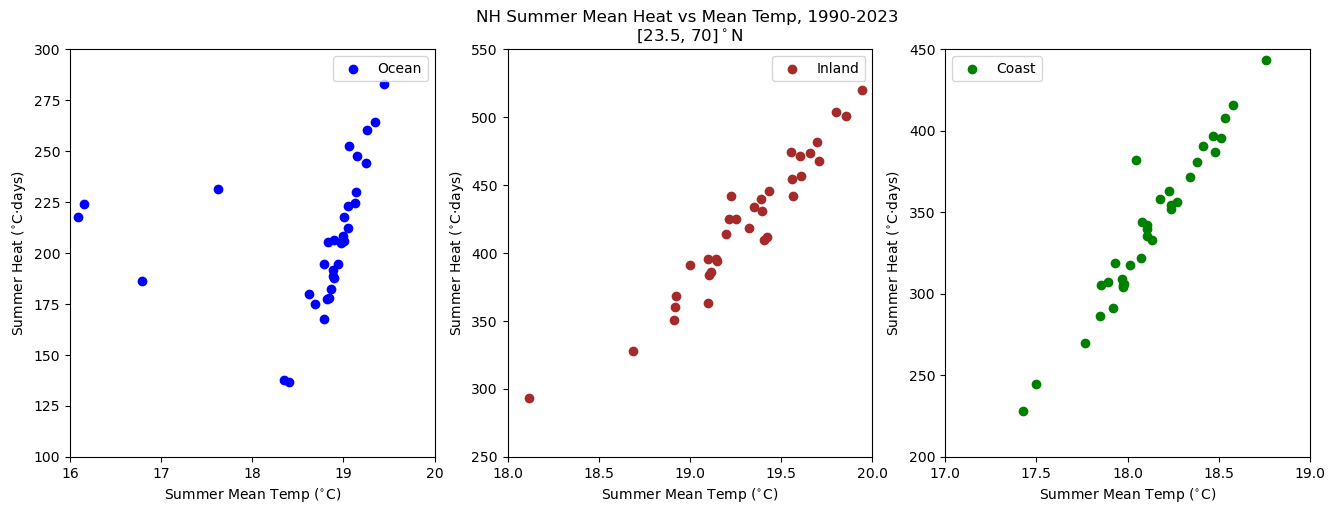

CPU times: user 142 ms, sys: 9.55 ms, total: 152 ms
Wall time: 151 ms


In [42]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)
plt.scatter(x=nh_ocean_an.SummerMeanT+KtoC, y=nh_ocean_an.SummerHeat, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(100,300)
plt.xlim(16,20)
plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)
plt.title("NH Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x=nh_land_an.SummerMeanT+KtoC, y=nh_land_an.SummerHeat, label="Inland", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(250,550)
plt.xlim(18,20)
plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)
plt.scatter(x=nh_coast_an.SummerMeanT+KtoC, y=nh_coast_an.SummerHeat, label="Coast", color='green')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(200,450)
plt.xlim(17,19)
plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()